# editing plots

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/ens.py -e RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 -v W --plotmean

In [1]:
import sys
sys.path.append('src/')
#import computeHx
import ens_test

In [1]:
from optparse import OptionParser
import sys
import os
import numpy as np
import datetime as DT 
import netCDF4 as ncdf
import glob
import pylab as P
from datetime import datetime
from src.plot_src.cbook2 import nice_mxmnintvl, nice_clevels
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy import ndimage


from matplotlib.colors import LinearSegmentedColormap, to_rgb

_bin_delta = 1
radar_hgt = 0

_prior_files = "Prior_*"
_plotfilename = "DBZ_ConsistencyRatio"

sec_utime = "seconds since 1970-01-01 00:00:00"


## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})


In [2]:
def smfnc(x):
    return ndimage.gaussian_filter(x, sigma=0.75)
    
# ------------------------------------------------------------------------------------------
# Search functions  each returns a boolean array of T/F with the same dimensions as field

def getIndexVariable(field, variable):
    return (field == variable)
    
def getIndexGreaterThan(field, value):
    return ( field > value )
    
def getIndexLessThan(field, value):
    return ( field < value )
    
def getIndexGreaterThanOrEqual(field, value):
    return ( field >= value )
    
def getIndexLessThanOrEqual(field, value):
    return ( field <= value )

def getIndexEqual(field, value):
    return ( field == value )

def getIndexNotEqual(field, value):
    return ( field != value )

def get_stats_timeseries(experiment_location, only_pos_dbz=True, variable='REF', full_field=False, dz=2000):
    '''experiment_location = path to the .exp file
       only_pos_dbz = if True, then only >10 dBZ is inluded in calculations (innovations will still include all data)
       variable = REFL or DBZ 
       full_field = if True, returns 2d field (x=time, y=height).
       dz is the size of the vertical bins'''

    if variable !='REF':
        only_pos_dbz=False
    
    dirname = os.path.join(experiment_location,_prior_files)
    #plotfilename='DBZ_CR'
    #noshow=True

    file_list = glob.glob(dirname)
    file_list = sorted(file_list,key=os.path.getmtime)

    bin_delta = _bin_delta

    nbins     = len(file_list) // bin_delta
    CR_T      = np.zeros((nbins))
    IN_T      = np.zeros((nbins))
    RMSI_T    = np.zeros((nbins))
    Spread_T  = np.zeros((nbins))

    if full_field:
        print('RETURNING 2D FIELDS')
        zbins    = dz*np.arange(int(8000/dz))
        print(zbins)
        CR_T     = np.zeros((zbins.size,nbins))
        IN_T     = np.zeros((zbins.size,nbins))
        RMSI_T   = np.zeros((zbins.size,nbins))
        Spread_T = np.zeros((zbins.size,nbins))

    datebins = []
    secsbins = []
    m = -1

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m+=1

            index_kind  = getIndexVariable(kind,variable)

            #### do a 1D timeseries for each variable
            if full_field == False: 
                if only_pos_dbz & ((variable=='REF')):
                    index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                    index       = index_kind & index_pos
                else:
                    index = index_kind
           
                if np.sum(index == True) > 2: 
                    
                    d           = dep[index] # innovation
                    obs_var     = error[index]
                    Hxftmp      = Hxf[index,:]
                    Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean() 
                    inno_var    = np.mean((d - d.mean())**2) 
                    RMSI_T[m]   = np.mean(np.sqrt((d - d.mean())**2))
                    
                    Spread_T[m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                    CR_T[m]     = (obs_var[1]**2 + Hxf_var) / inno_var # same thing as total spread squared / RMSI sqared
    
                    # for now, calculate innovations WITHOUT a positive DBZ filter (if you're using DBZ)
                    if only_pos_dbz:
                        d        = dep[index_kind] # innovation
                        IN_T[m]  = d.mean()
                    else:
                        IN_T[m]  = d.mean()

            #### return 2D fields
            else:
                for k in np.arange(zbins.size-1):
                    index1                = getIndexGreaterThanOrEqual(z, zbins[k])
                    index2                = getIndexLessThan(z, zbins[k+1])
                    if only_pos_dbz & ((variable=='REF')):
                        index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                        index             = index_kind & index1 & index2 & index_pos
                    else:
                        index             = index_kind & index1 & index2
        
                    if np.sum(index == True) > 2: 
                        d             = dep[index]
                        obs_var       = error[index]
                        Hxftmp        = Hxf[index,:]
                        Hxf_var       = Hxftmp.var(ddof=1, axis=1).mean()
                        inno_var      = np.mean((d - d.mean())**2)
                        CR_T[k,m]     = (obs_var[1]**2 + Hxf_var) / inno_var
                        RMSI_T[k,m]   = np.mean(np.sqrt((d - d.mean())**2))
                        Spread_T[k,m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                        if only_pos_dbz:
                            d         = dep[index_kind & index1 & index2] # innovation
                            IN_T[k,m] = d.mean()
                        else:
                            IN_T[k,m] = d.mean()
                            
        f.close()

    if full_field:
        datebins = [datebins, zbins]

    return datebins, CR_T, IN_T, Spread_T, RMSI_T


def format_time_ticks(ax, dates, minute_interval=10, approx_number_of_ticks=8,  tick_format='%H:%M', rotation=30, fontsize=14):
    ''' This does basic formatting to help clean up the plot cells'''

    start = dates[0].replace(second=0, microsecond=0)
    end   = dates[-1].replace(second=0, microsecond=0)
    ax.set_xlim(start, end)
    minute_interval = 5*round((end-start).seconds/(approx_number_of_ticks*60*5)) #find the best interval divisble by 5 based on nticks
    maj_loc = mdates.MinuteLocator(interval=minute_interval)
    ax.xaxis.set_major_locator(maj_loc)
    dateFmt = mdates.DateFormatter(tick_format)
    ax.xaxis.set_major_formatter(dateFmt)
    labels = ax.get_xticklabels()
    plt.setp(labels, rotation=30, fontsize=fontsize)


def CR_cmap():
    col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
    col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
    col1.extend(col2)
    clist = [to_rgb(c) for c in col1[::-1]]
    i1,i2 = 9,11
    clist[i1:i2] = np.array(clist[i1:i2])*1.18
    cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
    return cmap

In [7]:
import xarray as xr
f = xr.open_dataset(file_list[0])


In [12]:
np.unique(f.type)

array([b'', b'REF', b'VR'], dtype='|S8')

In [5]:
experiment_location='/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR'
experiment_location = '/work/jessica.mcdonald/CM1_LETKF_2025/test'

dirname = os.path.join(exps[0],_prior_files)
plotfilename='DBZ_CR'
noshow=True

file_list = glob.glob(dirname)
file_list = sorted(file_list,key=os.path.getmtime)

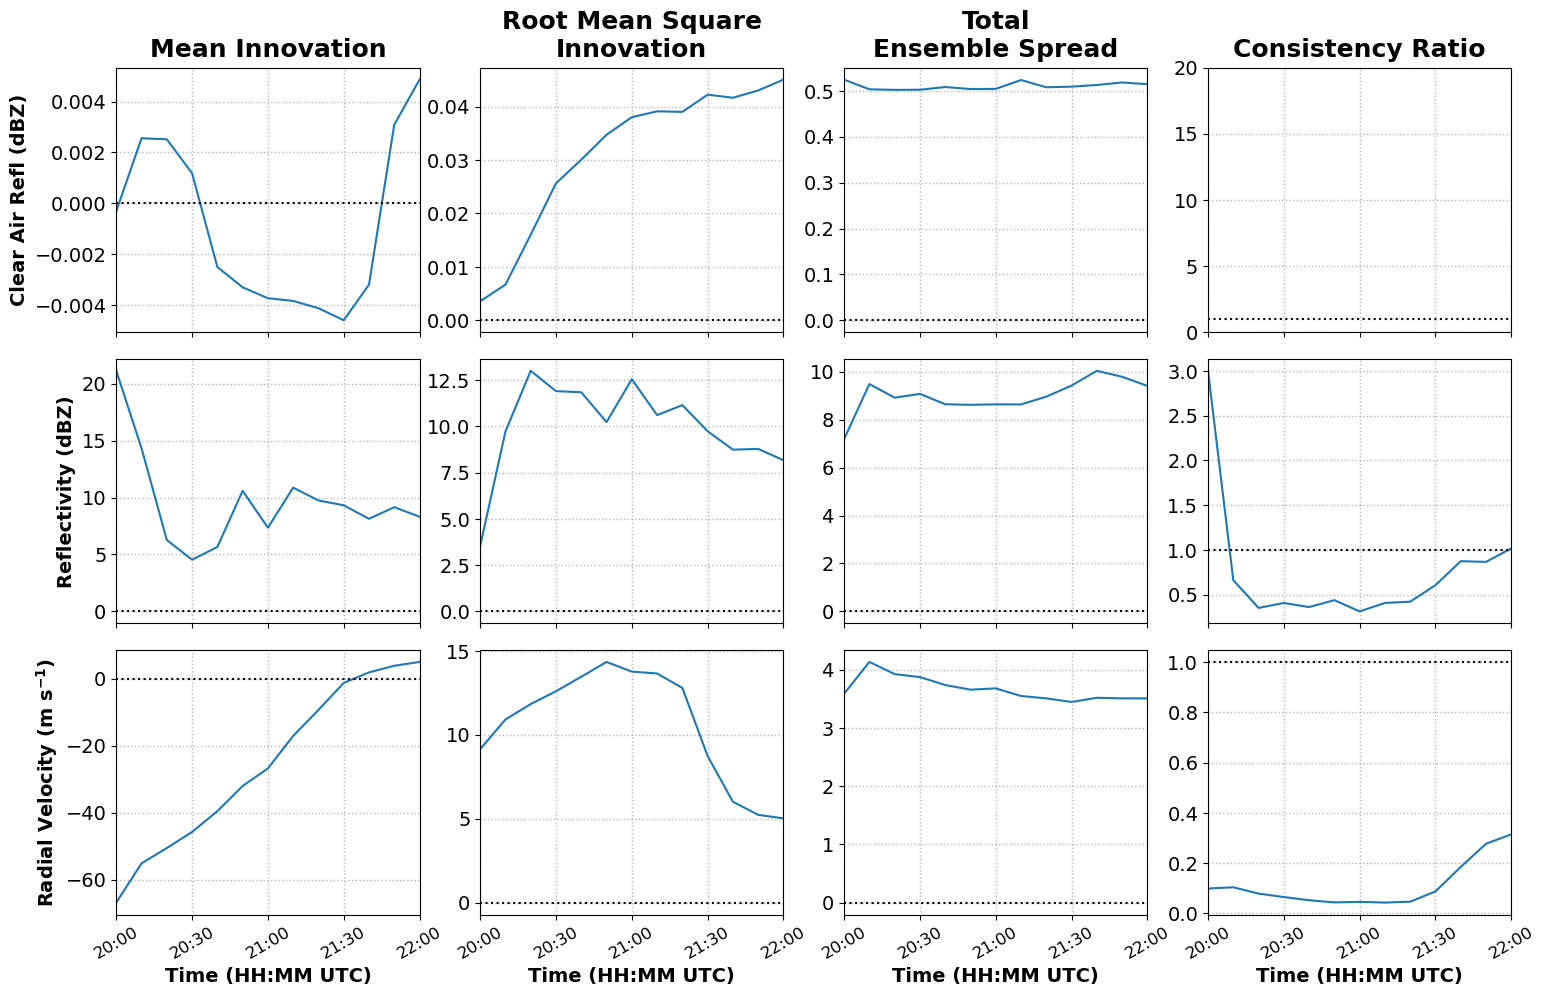

In [13]:
labels = ['no outliers', ' with outliers', 'update w']

exps = ['/work/jessica.mcdonald/CM1_LETKF_2025/test','/work/jessica.mcdonald/CM1_LETKF_2025/test_outliers',
        '/work/jessica.mcdonald/CM1_LETKF_2025/test_w']


exps = [
        '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w']
#experiment_location = 

fig,axes = plt.subplots(3,4, figsize=(18,11), sharex=True)


axes[0,0].set_title('Mean Innovation', weight='bold', y=1.01)
axes[0,1].set_title('Root Mean Square\nInnovation', weight='bold', y=1.01)
axes[0,2].set_title('Total\nEnsemble Spread', weight='bold', y=1.01)
axes[0,3].set_title('Consistency Ratio', weight='bold', y=1.01)

max_CR=[]

for i,exp in enumerate(exps):

    for ii,var in enumerate([ '', 'REF', 'VR']):

        dates, CR, IN, SPRD, RMSI = get_stats_timeseries(exp, only_pos_dbz=True, variable=var)
        max_CR.append(np.max(CR))
        axes[ii,0].plot(dates, IN,   label=labels[i])
        axes[ii,1].plot(dates, RMSI, label=labels[i])
        axes[ii,2].plot(dates, SPRD, label=labels[i])
        axes[ii,3].plot(dates, CR,   label=labels[i])

# formatting
plt.subplots_adjust(hspace=0.1)
for ax in axes[-1,:].flatten():
    format_time_ticks(ax, dates, fontsize=12, approx_number_of_ticks=4)
    ax.set_xlabel('Time (HH:MM UTC)')
for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
for ax in axes[:,[0,1,2]].flatten():
    ax.axhline(0, ls=':', color='k')
for ax in axes[:,3].flatten():
    ax.axhline(1, ls=':', color='k')

# share ylim but only for the CR plot
# if max_CR[0] > max_CR[1]:
#     axes[1,3].sharey(axes[0,3])
# else:
#     axes[0,3].sharey(axes[1,3])

axes[0,3].set_ylim(0, 20)
#axes[1,3].set_ylim(0, 50)
#axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');
axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');
axes[1,0].set_ylabel('Reflectivity (dBZ)', weight='bold');
axes[2,0].set_ylabel(r'Radial Velocity (m s$\mathbf{^{-1}}$)', weight='bold');

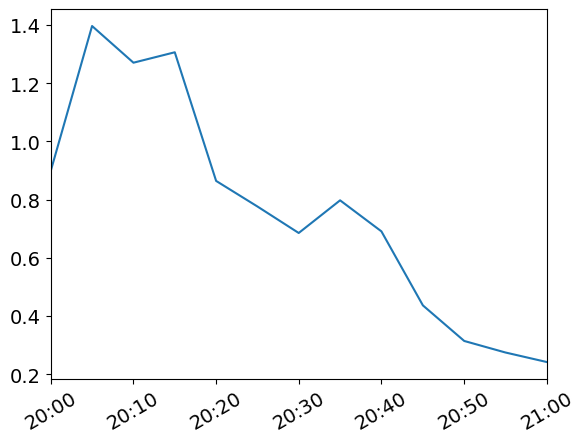

In [11]:
fig, ax=plt.subplots(1)

ax.plot(dates, CR)
format_time_ticks(ax, dates)

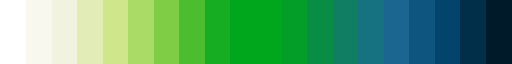

In [156]:
colors = ['#f7f7f7','#ededeb','#cbe681', '#71c93a',   '#00a61c', \
          '#40bcc7',  '#86d9f0', '#def5fc','#f7f7f7']

colors = ['#ffffff','#f2f2df','#cbe681', '#71c93a',   '#00a61c',  '#00a61c',\
          '#0d8259',  '#1e6996', '#044770','#001a29']

clist = [np.array(to_rgb(c))*1 for c in colors]
clist[4] = np.array(to_rgb('#00a61c'))
cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
cmap

In [170]:
for c in col1:
    print(c)

[1.         1.         0.89803922 1.        ]
[0.9812995  0.99298731 0.79518647 1.        ]
[0.94232987 0.97771626 0.70620531 1.        ]
[0.86851211 0.94818916 0.65207228 1.        ]
[0.76842753 0.90552864 0.59981546 1.        ]
[0.65642445 0.85711649 0.54814302 1.        ]
[0.52601307 0.80052288 0.49647059 1.        ]
[0.39277201 0.7382699  0.43489427 1.        ]
[0.25743945 0.67183391 0.36599769 1.        ]
[0.18246828 0.57642445 0.30193003 1.        ]
[array([0.18246828, 0.59784698, 0.34443676, 1.        ]), array([0.256609  , 0.68327566, 0.46486736, 1.        ]), array([0.3476509 , 0.7324875 , 0.57805459, 1.        ]), array([0.45333333, 0.78379085, 0.68183007, 1.        ]), array([0.57882353, 0.83792388, 0.77287197, 1.        ]), array([0.70431373, 0.88796617, 0.84755094, 1.        ]), array([0.81460977, 0.93074971, 0.91306421, 1.        ]), array([0.87612457, 0.95289504, 0.95981546, 1.        ]), array([0.92655133, 0.97187236, 0.98280661, 1.        ]), array([0.96862745, 0.98823

In [5]:
import cmocean

In [6]:
import cmasher as cmr

40
35
30
25
20


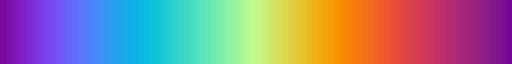

In [44]:
col = list(cmr.infinity(np.linspace(0, 1, 100)))

clist = [to_rgb(c) for c in col]
clist = [np.array(c)*1.3 for c in clist]

clist[0:50] = np.array(clist[0:50])*1.02

clist[0:45] = np.array(clist[0:45])*1.01
for i in np.arange(40, 15, -5):
    print(i)
    clist[0:i] = np.array(clist[0:i])*1.01
cmap = LinearSegmentedColormap.from_list("CR", clist, 100)
cmap

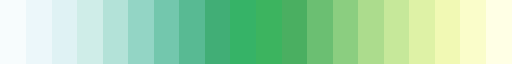

In [246]:
col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
col1.extend(col2)
clist = [to_rgb(c) for c in col1[::-1]]
i1,i2 = 9,11
clist[i1:i2] = np.array(clist[i1:i2])*1.18
cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
#return cmap

#cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
cmap

RETURNING 2D FIELDS
[   0 2000 4000 6000]
RETURNING 2D FIELDS
[   0 2000 4000 6000]


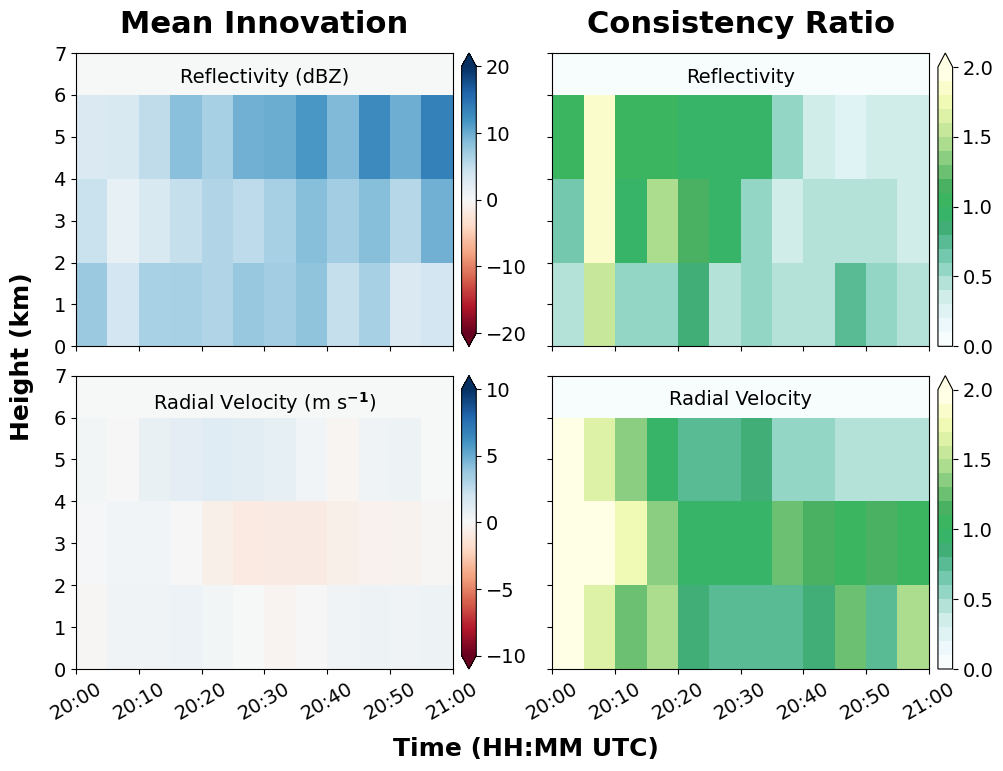

In [102]:
fig, axes = plt.subplots(2,2, figsize=(12,8), sharey=True, sharex=True)

vals = [20, 10]
fs = 14
cmap = CR_cmap()

for ii,var in enumerate(['REF', 'VR']): 
    TZ, CR, IN, SPRD, RMSI = get_stats_timeseries(experiment_location, only_pos_dbz=True, variable=var, full_field=True, dz=2000)
    t, z = list(TZ[0]), list(TZ[1]/1000)
    z.append(z[-1]+z[1]-z[0])
    t.append(t[-1]+(t[1]-t[0]))
    im1 = axes[ii,0].pcolormesh(t,z, IN, vmin=-1*vals[ii], vmax=vals[ii], cmap='RdBu')
    im2 = axes[ii,1].pcolormesh(t,z, CR, vmin=0, vmax=2, cmap=cmap)

    if ii ==1:format_time_ticks(axes[ii,0],t[:-1]);format_time_ticks(axes[ii,1],t[:-1])

    if ii==0: 
        axes[ii,0].text(0.5, .95, 'Reflectivity (dBZ)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Reflectivity',       ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    if ii==1: 
        axes[ii,0].text(0.5, .95, r'Radial Velocity (m s$\mathbf{^{-1}}$)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Radial Velocity',                        ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    plt.colorbar(im1, ax =axes[ii,0], pad=.02, extend='both')
    plt.colorbar(im2, ax =axes[ii,1], pad=.02, extend='max') 

axes[0,0].set_ylim(0,7)

plt.subplots_adjust(hspace=.1, wspace=0.05)

axes[0,0].set_title('Mean Innovation',   weight='bold',fontsize=22, y=1.04)
axes[0,1].set_title('Consistency Ratio', weight='bold',fontsize=22, y=1.04)

fig.text(0.5, 0.01, 'Time (HH:MM UTC)', ha='center', va='center', weight='bold', fontsize=18);
fig.text(0.07,0.5, 'Height (km)', weight='bold', va='center', fontsize=18, rotation='vertical');

In [120]:
index

False

In [26]:
dirname = os.path.join(exps[1],_prior_files)
#plotfilename='DBZ_CR'
#noshow=True

bin_delta=1

file_list = glob.glob(dirname)
file_list = sorted(file_list,key=os.path.getmtime)

full=[]
fop = []
variable='REF0'

    #full.append( value[index] - Hxf[index,:] ) #hxfbar is the mean model values

for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            #datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))


            index_kind  = getIndexVariable(kind,variable)

            temp = (dep[index_kind][:])# - Hxf[index_kind,:])
            temp2 = Hxf[index_kind,:]
            if n == 0:
                full = temp.copy()
                fop = temp2.copy()
            else:
                full = np.concat([full, temp], axis=0)
                fop = np.concat([fop, temp2], axis=0)
            

In [141]:
np.min(full)

np.float64(-114.07939372629815)

5591


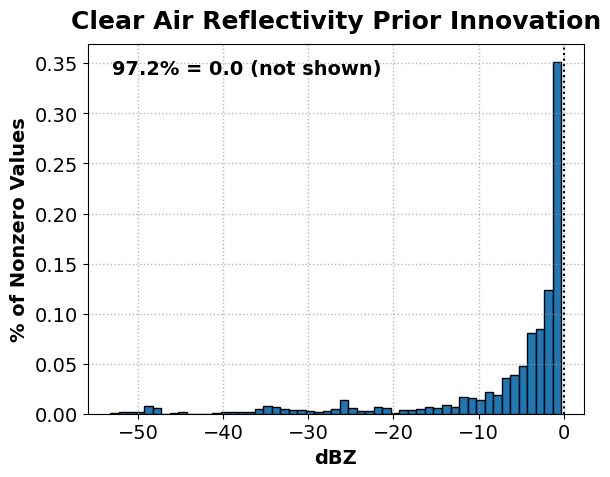

In [27]:
eqzero = 100*list(full.flatten()).count(0.0)/len(full.flatten())
bins = np.arange(np.min(full), 0, 1)
counts, bin_edges  = np.histogram(full.flatten(), bins=bins)
#ncounts, nbin_edges  = np.histogram(full.flatten(), bins=bins)

print(sum(counts))
#print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
#nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Clear Air Reflectivity Prior Innovation', weight='bold', y=1.02)
plt.bar(bin_c, counts/sum(counts), width=1, edgecolor='k')

plt.text(0.05, .96, f"{eqzero:.1f}% = 0.0 (not shown)",va='top', fontsize=14, weight='bold', transform=plt.gca().transAxes)

plt.xlabel('dBZ')
plt.ylabel('% of Nonzero Values')
plt.axvline(0, color='k', ls=':')
plt.grid(ls=":", alpha=0.7)

/tmp/ipykernel_1466515/2940125403.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))


Text(0.5, 0, 'Time (UTC)')

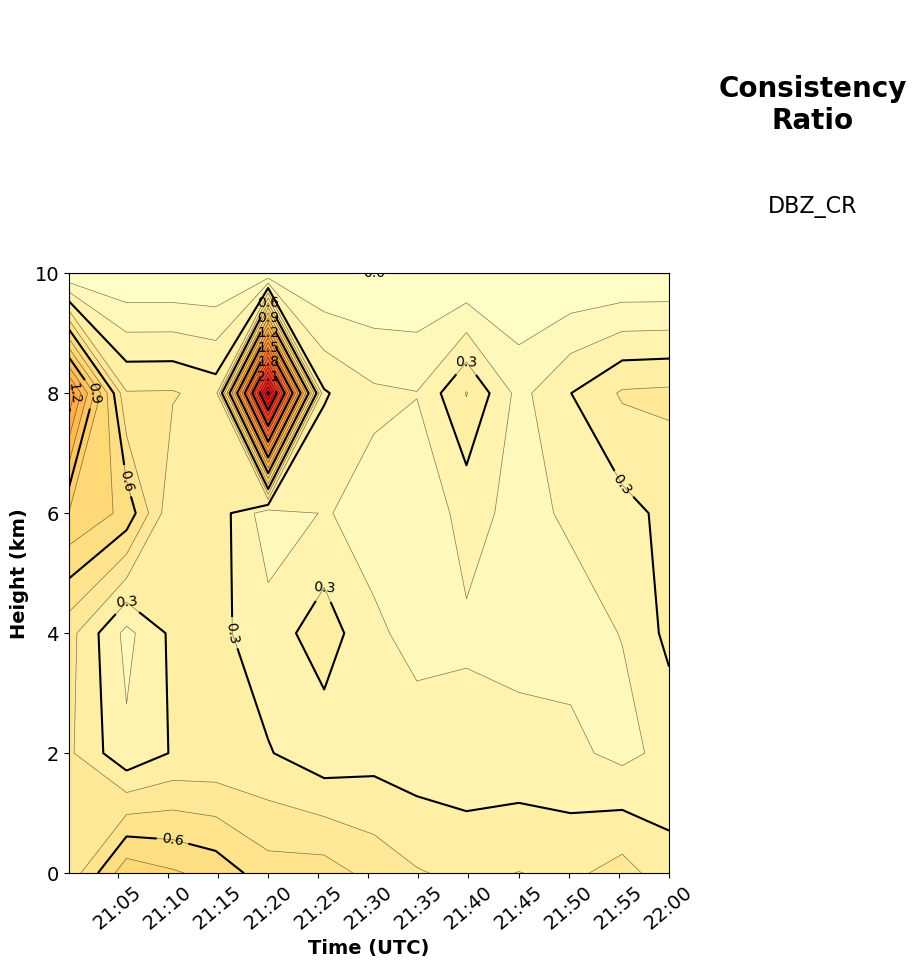

In [5]:
_cmin, _cmax = 0.0, 1.1   # limits for the single line plots...

variable = "VR"   # valid variables:  VR, DBZ
variable = 11   # valid variables:  VR, DBZ

sec_utime = "seconds since 1970-01-01 00:00:00"
auto_clevels = True

# definitions for the plot layout with multiple panels
left, width = 0.1, 0.5
bottom, height = 0.1, 0.5
bottom_h = left_h = left+width+0.03

rectC = [left, bottom, width, height]
rectX = [left, bottom_h, width, 0.2]
rectY = [left_h, bottom, 0.2, height]

fig = P.figure(figsize=(12,12))
fig.text(0.72, 0.72, "\n\nConsistency\nRatio", size=20, va="baseline", ha="center", multialignment="center", weight='bold')
fig.text(0.72, 0.65, plotfilename, size=16, va="baseline", ha="center", multialignment="center")


axC = P.axes(rectC)

zmin, zmax, cint = nice_mxmnintvl(zbins.min()/1000., zbins.max()/1000., outside=True, cint=1.0)
zmin = 0.0

if auto_clevels:
    cmin, cmax, cint, clevels = nice_clevels(0, 3, outside=False, cint = 0.1)
else:
    clevels = np.arange(spread_limits[0], spread_limits[1], spread_limits[2])

cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))
axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k', linewidths=0.5, alpha=0.5)
cs2=axC.contour(datebins,  zbins/1000., CR_TZ, cs1.levels[::3], colors='k')

start = datebins[0]
end   = datebins[-1]

nticks_approx = 8
minute_interval = 5*round((end-start).seconds/(nticks_approx*60*5)) #find the best interval divisble by 5 based on nticks

axC.set_xlim(start, end)
axC.set_ylim(zmin,zmax)

maj_loc = mdates.MinuteLocator(interval=minute_interval)
axC.xaxis.set_major_locator(maj_loc)
dateFmt = mdates.DateFormatter('%H:%M')
axC.xaxis.set_major_formatter(dateFmt)

labels = axC.get_xticklabels()
P.setp(labels, rotation=40, fontsize=14)

axC.clabel(cs2, inline=1, fontsize=10, fmt="%1.1f")
axC.set_ylabel("Height (km)", weight='bold')
axC.set_xlabel("Time (UTC)",weight='bold')

# ens stuff

In [116]:
import netCDF4 as ncdf
import numpy as N
import math as M
import glob
import sys
import os
import re

import matplotlib
import matplotlib.pyplot as P
from matplotlib import ticker
from matplotlib.offsetbox import AnchoredText

import json
from pyproj import Proj
from time import time as timer
from pyDart import dll_2_dxy, dxy_2_dll
import pyDart
import datetime
from subprocess import *
#from cbook2 import *
import ctables
from optparse import OptionParser
import scipy.interpolate
import scipy.ndimage as ndimage
import scipy.spatial

from mpl_toolkits.basemap import Basemap

from fsrc.fpython2 import fstate, addbubbles_box, obs_2_grid3d
from fsrc.fpython2 import add_smooth_perts
#import fsrc.recursive2d as recursive2d

import state_vector as state

In [6]:
files = ['a']
for n, file in enumerate(files):
  print(file)
  # f = ncdf.Dataset(file, "r") # this makes no sense but may fix an hdf bug
  # f.close()

  try:  
    f = ncdf.Dataset(file, "r+")
  except OSError:
    print('failed to load {file} in edit mode, trying again')
    f = ncdf.Dataset(file, "r") # this makes no sense but may fix an hdf bug
    f.close()
      
  try:  
    f = ncdf.Dataset(file, "r+")
  except OSError:
    print('failed to load {file} in edit mode, trying again')
    f = ncdf.Dataset(file, "r") # this makes no sense but may fix an hdf bug
    f.close()

  try:  
    f = ncdf.Dataset(file, "r+")
  except OSError:
    print('had to give up. Try something else. ')

a


In [20]:
myDTstring = '2003,5,8,20,45,0'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)

files, myDT = FindRestartFiles(exper, myDTstring, ret_exp=False,)
state = read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens_CM1_coords(state)
#ens_check(files, state)

ens_IC_pertUV(state, writeout=False)
ens_IC_pert_from_box(state, plot=False, writeout=False)


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 20:45:00

 ==> FindRestartFile:  Found time 300 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000001.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2003-05-08 20:45:00 


 Wallclock time for serial read netCDF ensemble files: 0.096  sec

 Wallclock time to convert from C to A grid: 0.019  sec

 Wallclock time to create ensemble means: 0.068  sec

 Wallclock time to read arrays from netCDF ensemble files: 0.229  sec

 Wallclock time to create coordinates: 0.0  sec

 ==> ens_IC_pertUV: Max/Min  u  perturbations: 4.713547448587625 -4.935828675819298

 ==> ens_IC_pertUV: Max/Min  v  perturbations: 4.922844101235247 -4.911479334075609

 ==> ens_IC_pertUV: Mean u/v perturbations (should be close to zero): -

In [31]:
np.shape(fstate.v)

(4, 51, 76, 75)

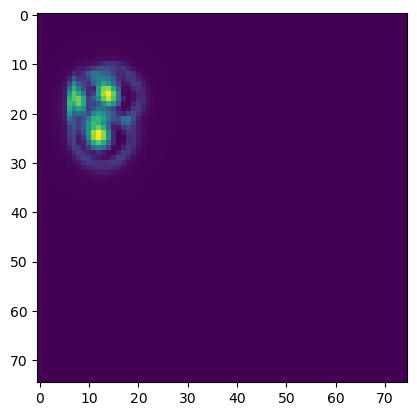

In [27]:
plt.imshow(state.TH[:][0, 4,:,:])

In [26]:
import matplotlib.pyplot as plt

In [22]:
for var in state['state_vector']['xyz3d']:
    print(np.shape(state[var][:]))

(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)
(4, 51, 75, 75)


In [2]:
def write_CM1_ens(ens, writeEns=False, overwrite=False, writeFcstMean=False, writeAnalMean=False, HF=None):

  """
    Writes out all 3D variables back to the CM1v18 restart netCDF4 files.  
    
    If writeEns == True, write out the entire ensemble back to disk.
    
    If overwrite == True, overwrite the CM1 restart files that were read into the ens data structure.  The 'prior' 
       forecast data will be lost, hence its almost never a good idea to set this to True, unless you are 
       desparate for disk space or something else that is not normal. 
    
    If overwrite == False, the original restart files are copied from XXXXX_rst_000XXX.nc to XXXXX_prior_000XXX.nc
       in each member directory.  Then the ens state data are written back into the XXXXX_rst_000XXX.nc files.  
       Therefore the "prior" files hold the forecasts, and the "rst" files are the new analysis states.

    If writeAnalMean == True, then place a file into the "member000" directory called XXXXX_post_000XXX.nc
        
    If writeFcstMean == True, then place a file into the "member000" directory called XXXXX_prior_000XXX.nc
        
    If the state vector does not include a variable, none is written to the netCDF file.  
    
    Example:  If you choose not to read in a variable, say, number concentration of ice, then it will not be
              available in the state vectors array to be written out (either as the fcst/analysis mean, etc).
              
    Also, only rank-3 state vectors are currently copied.  The rank-0 (scalars like NX) and rank-1 (1D arrays like ZC)
          are assumed to be already in the file when it was created.
  """

  t0 = timer()

#-----------------------------------------------------------------------------------------      
# If OVERWRITE....

  f = ncdf.Dataset(ens.files[0], "r")
  time = f.variables['time'][:]
  f.close()
  del(f)

  if writeEns == True:
  
    time_index = ens.time_index
    t_index    = time_index

    print("\n ==> WRITE_CM1_ENS:  Writing ensemble into time_index %d at time %d" % (time_index, time[time_index]))

    if overwrite == True:

      print("\n ==> WRITE_CM1_ENS: WARNING:  Overwriting CM1 restart file, no fcst restart files will be saved")

    else:

      for file in ens.files:

# Here we take the current forecast file and copy it to a new netCDF file with a slightly different name

        #cmd = "cp %s %s" % (file, file.replace("_rst_", "_prior_"))
        cmd = "cp %s %s" % (file, file.replace("rst_", "_prior_")) #new version
        os.system(cmd)

      print("\n ==> WRITE_CM1_ENS:  CM1 prior files creation completed")

#-----------------------------------------------------------------------------------------      
# Automatically compute C-grid velocities from stored A-grid velocities - this is automatic now

    ens_CM1_A2C(ens)
    
#-----------------------------------------------------------------------------------------      
# Writing out xyz3d to each ensemble member

    if HF == None:
        files = ens.files
    else:
        files = ens.files[HF::2]
        print(files)
        print("\n ==> WRITE_CM1_ENS HF on, starting at  %d" % (HF))
        print("\n ==> WRITE_CM1_ENS HF on, First file to writeback  %s" % (files[0] ))
        print("\n ==> WRITE_CM1_ENS HF on, Last file to writeback:  %s" % (files[-1]))

    for n, file in enumerate(files):

      f = ncdf.Dataset(file, "r+")

      for key in ens.state_vector['xyz3d']:
      
        if ens.state_vector[key]['writeback']:
      
          if key == "U":        
            f[ens.state_vector[key]['name']][:,:,:] = fstate.u[n,:,:,:]
      
          elif key == "V":  
            f[ens.state_vector[key]['name']][:,:,:] = fstate.v[n,:,:,:]

          elif key == "W":  
            f[ens.state_vector[key]['name']][:,:,:] = fstate.w[n,:,:,:]

          else:          
            f[ens.state_vector[key]['name']][:,:,:] = ens.__dict__[key][n,:,:,:]
   
        else:
          if debug_io:
            print("\n ==> WRITE_CM1_ENS:  Did not writeback variable %s to netCDF file" % key)
          
      #f.sync()
      f.close()
      del(f)

      if debug_io:
        print("\n ==> WRITE_CM1_ENS:  Closed file %s" % files[n])

# End writing out ensemble files to CM1 restart files.      
#-----------------------------------------------------------------------------------------            
# IF writeFcstMean == True or writeAnalMean == True, write out mean state...

  if writeFcstMean == True or writeAnalMean == True:

# if user forgot to create the mean, do it here

    if ens.addmean != 1:
      ens_CM1_mean(ens)
      ens.addmean = 1

# Does a member000 directory exist for mean analyses?

    member000_dir = os.path.join(ens.experiment['base_path'],"member000")

    if os.path.isdir(member000_dir) != True:
      os.mkdir(member000_dir)

    if writeAnalMean == True:
      #meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("_rst_", "_post_"))
      meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("rst_", "_post_"))
      print("\n ==> WRITE_CM1_ENS:  Now writing out posterior ensemble mean into %s" % (meanfile))
    else:
      #meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("_rst_", "_prior_"))
      meanfile = os.path.join(member000_dir, os.path.basename(ens.files[0]).replace("rst_", "_prior_"))
      print("\n ==> WRITE_CM1_ENS:  Now writing out prior ensemble mean into %s" % (meanfile))
    
    cmd = "cp -f %s %s" % (ens.files[0], meanfile)
    os.system(cmd)

    f = ncdf.Dataset(meanfile, format='NETCDF4')

    for key in ens.state_vector["xyz3d"]: 
      
      if key in f.variables:

        if key == "U":        
          f[ens.state_vector[key]['name']][0,:,:,:] = fstate.u[ens.ne,:,:,:]
      
        elif key == "V":  
          f[ens.state_vector[key]['name']][0,:,:,:] = fstate.v[ens.ne,:,:,:]

        elif key == "W":  
          f[ens.state_vector[key]['name']][0,:,:,:] = fstate.w[ens.ne,:,:,:]

        else:          
          f[ens.state_vector[key]['name']][0,:,:,:] = ens.__dict__[key][ens.ne,:,:,:]
        
    f.sync()
    f.close()

    print("\n ==> WRITE_CM1_ENS:  Closed file %s" % meanfile)

# End writing out full ensemble forecast or analysis files.      
#---------------------------------------------------------------------------------------------------
#
  if time_all:  print("\n ==> Wallclock time to write out fcst/anal to files:", round(timer() - t0, 3), " sec")

  return


In [7]:
myDTstring = '2003,5,8,20,45,0'

with open('/work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/RUN_LETKF.exp', 'rb') as f:
    exper = json.load(f)

files, myDT = FindRestartFiles(exper, myDTstring, ret_exp=False,)
state = read_CM1_ens(files, exper, state_vector=None, DateTime=myDT, addmean=1)
ens_CM1_coords(state)
#ens_check(files, state)

ens_IC_pertUV(state, writeout=False)
ens_IC_pert_from_box(state, plot=False, writeout=False)
write_CM1_ens(state, writeEns=True, overwrite=False)

# for n, file in enumerate(files[0:1]):


#       f = ncdf.Dataset(file, "r")
    
#       for key in state.state_vector['xyz3d']:
      
#         if state.state_vector[key]['writeback']:
      
#           if key == "U":        
#             f[state.state_vector[key]['name']][:,:,:] = fstate.u[n,:,:,:]
      
#           elif key == "V":  
#             f[state.state_vector[key]['name']][:,:,:] = fstate.v[n,:,:,:]

#           elif key == "W":  
#             f[state.state_vector[key]['name']][:,:,:] = fstate.w[n,:,:,:]

#           else:          
#             f[state.state_vector[key]['name']][:,:,:] = state.__dict__[key][n,:,:,:]
   
#         else:
#           if debug_io:
#             print("\n ==> WRITE_CM1_ENS:  Did not writeback variable %s to netCDF file" % key)
          


 ==> FindRestartFiles: Date and time supplied is 2003_05_08 20:45:00

 ==> FindRestartFile:  Found time 300 in file:  /work/jessica.mcdonald/CM1_LETKF_2025/RUN_LETKF/member001/cm1rst_000001.nc

 ==> READ_CM1_ENS:  No state_vector supplied - trying to match microphysics schemes

 ==> READ_CM1_ENS ==> Matching state_vector found !!! using zvdh

 ==> READ_CM1_ENS: reading from time INDEX:  0
 ==> READ_CM1_ENS: reading from state TIME:  2003-05-08 20:45:00 



ValueError: could not broadcast input array from shape (52,51,75,76) into shape (51,75,76)

In [3]:
f = ncdf.Dataset(file, "r")

In [5]:
key="U"
f[state.state_vector[key]['name']]

<class 'netCDF4._netCDF4.Variable'>
float32 ua(time, nk, nj, nip1)
    long_name: west-east velocity (at u points)
    units: m/s
unlimited dimensions: time
current shape = (1, 51, 75, 76)
filling on, default _FillValue of 9.969209968386869e+36 used